<a href="https://colab.research.google.com/github/princemwaanga/J-Drop/blob/main/Weather_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model Evaluation Metrics:
Mean Absolute Error: 2.33
Mean Squared Error: 6.44
Root Mean Squared Error: 2.54


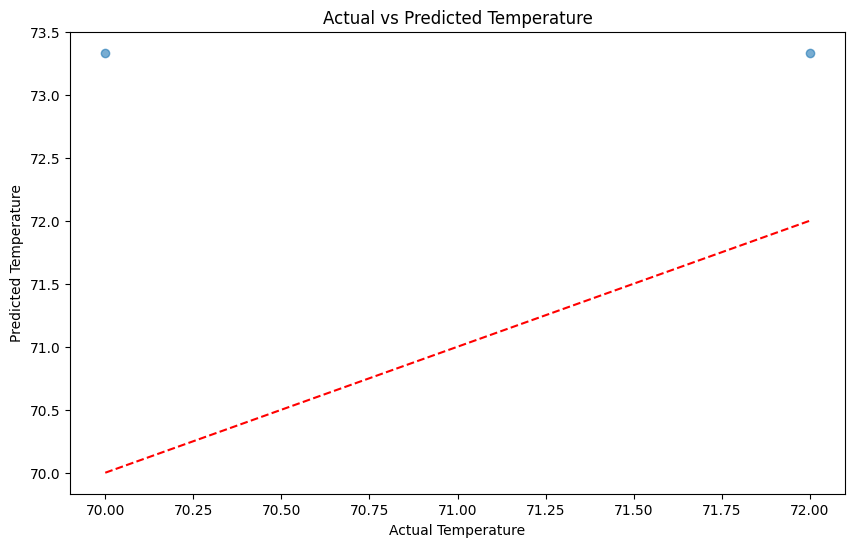


Predicted temperature for tomorrow: 73.0°F


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:

import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Load historical weather data (example dataset)
# Replace this with your actual data source
def load_weather_data():
    # Sample data structure - replace with your real data
    data = {
        'temperature': [72, 75, 68, 65, 70, 78, 80, 76, 74, 71],
        'humidity': [60, 65, 70, 75, 68, 55, 50, 58, 62, 64],
        'pressure': [1010, 1012, 1008, 1005, 1011, 1015, 1016, 1013, 1010, 1009],
        'wind_speed': [5, 8, 12, 15, 7, 6, 4, 9, 10, 8],
        'precipitation': [0, 0, 0.2, 0.5, 0, 0, 0, 0.1, 0, 0],
        'next_day_temp': [74, 70, 66, 68, 75, 79, 77, 75, 72, 70]  # Target variable
    }
    return pd.DataFrame(data)

# Preprocess data
def preprocess_data(df):
    # Separate features and target
    X = df.drop('next_day_temp', axis=1)
    y = df['next_day_temp']

    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Standardize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test, scaler

# Train KNN model
def train_knn_model(X_train, y_train, n_neighbors=5):
    model = KNeighborsRegressor(n_neighbors=n_neighbors)
    model.fit(X_train, y_train)
    return model

# Evaluate model
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print(f"Model Evaluation Metrics:")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")

    # Plot actual vs predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r')
    plt.xlabel('Actual Temperature')
    plt.ylabel('Predicted Temperature')
    plt.title('Actual vs Predicted Temperature')
    plt.show()

# Make a prediction for new weather data
def predict_weather(model, scaler, new_data):
    # Ensure new_data is in the same format as training data
    new_data_scaled = scaler.transform([new_data])
    prediction = model.predict(new_data_scaled)
    return prediction[0]

# Main function
def main():
    # Load and preprocess data
    weather_df = load_weather_data()
    X_train, X_test, y_train, y_test, scaler = preprocess_data(weather_df)

    # Train model
    knn_model = train_knn_model(X_train, y_train, n_neighbors=3)

    # Evaluate model
    evaluate_model(knn_model, X_test, y_test)

    # Example prediction
    new_weather = [70, 65, 1010, 8, 0]  # [temp, humidity, pressure, wind_speed, precipitation]
    predicted_temp = predict_weather(knn_model, scaler, new_weather)
    print(f"\nPredicted temperature for tomorrow: {predicted_temp:.1f}°F")

if __name__ == "__main__":
    main()